# Mineral Exploration Budget Allocation: A Python Optimisation Project

From "Resouces and energy quarterly: June 2026" in the Department of Industry, Science and Resources, it was forecasted that export earnings for gold can reach $73 billion from 2026-2027. We can simply investigate this claim on a mathematical scale using a simple constrained linear programming approach. Using datasheets extracted from the full report, prices.csv contains the prices per commodity on a monthly basis, while expenditure.csv contains yearly expenditures per listed mineral.

The decision variables are as follows:
    * x_gold = proportion of total budget allocated to Gold exploration
    * x_iron = proportion or total budget allocated to Iron ore exploration
    
The objective function Z is to be maximized:
    Z = r_gold * x_gold + r_iron * x_iron
    
    where x_gold and x_iron are budgets allocated,
    
    and r_gold and r_iron are correlation coefficients calculated according to responsiveness of prices based on historical exploration

Constraints:
    1. x_gold + x_iron = 1 (the full budget must be allocated)
    2. x_gold >= 0, x_iron >= 0 (no negative allocation)
    3. 0 <= x_gold <= 0.7, 0 <= x_iron <= 0.7 (minimum allocation is 0 and maximum is 70%)

## Library imports

In [38]:
import pandas as pd
import numpy as np
import sqlite3
from IPython.display import display
from scipy.optimize import linprog
import matplotlib.pyplot as plt

In [23]:
prices = pd.read_csv('prices.csv')
expenditure = pd.read_csv('expenditure.csv')

## Load cleaned dataframes into SQL tables 

In [24]:
#Turn prices from long to wide

prices_long = prices.melt(id_vars = 'Financial Year',
                         value_vars = ['Gold prices AUD', 'Iron ore prices AUD'],
                         var_name = 'Commodity', value_name = 'Price')
exp_long = expenditure.melt(id_vars = 'Year',
                           value_vars = ['Gold', 'Iron ore'],
                           var_name = 'Commodity', value_name = 'Expenditure')

In [25]:
#Show melted dataframe
display(exp_long)

,Year,Commodity,Expenditure
0,1990,Gold,341
1,1991,Gold,306
2,1992,Gold,305
3,1993,Gold,320
4,1994,Gold,454
...,...,...,...
65,2020,Iron ore,361
66,2021,Iron ore,473
67,2022,Iron ore,646
68,2023,Iron ore,708


In [27]:
# Clean up values to match
prices_long['Commodity'] = prices_long['Commodity'].str.replace(' prices AUD', '')

#Merge 
merged_df = pd.merge(
exp_long,
prices_long,
left_on = ['Year','Commodity'],
right_on = ['Financial Year', 'Commodity'])

it worked


In [30]:
#filter rows to pull numeric series for correlation
gold_exp = exp_long[exp_long['Commodity'] == 'Gold']['Expenditure']
gold_price = prices_long[prices_long['Commodity'] == 'Gold']['Price']

r_gold = gold_exp.corr(gold_price)

iron_exp = exp_long[exp_long['Commodity'] == 'Iron ore']['Expenditure']
iron_price = prices_long[prices_long['Commodity'] == 'Iron ore']['Price']

r_iron = iron_exp.corr(iron_price)

#Print calculated corr coefficients
print("r_gold = ", r_gold)
print("r_iron = ", r_iron)

r_gold =  0.8595131646975149
r_iron =  0.6955902270223416


Based on the correlation scores, Gold has a higher price responsiveness score of 0.86 compared to Iron ore. Using the linprog from scipy, we determine the optimal proportion of the budget that needs to be allocated per mineral.

In [37]:
#Setup objective function coefficients and negate to maximize
c = [-r_gold, -r_iron]

#Setup equality constraint
A_eq = [[1, 1]]
b_eq = [1]

bounds = [(0, 0.7), (0, 0.7)]
#Solve using linprog from scipy

result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds = bounds)
x_gold_opt, x_iron_opt = result.x

print(f"Optimal Gold allocation: {x_gold_opt:.1%}")
print(f"Optimal Iron ore allocation: {x_iron_opt:.1%}")

Optimal Gold allocation: 70.0%
Optimal Iron ore allocation: 30.0%


The resulting allocation is that Gold receives 70% of the budget while Iron ore received the remaining budget due to its lower individual correlation. This budget allocation will reflect a higher total portfolio score whih will be explored in depth through a sensitivity analysis.

## Sensitivity Analysis

This section tackles the following analyses:
    1. The correlation value r_iron the LP optimizer shifts it priority from Gold to Iron
    2. How varying the upper bound constraint changes the overall objective value Z

In [44]:
#Subtract correlation coefficients to know what value it needs to adjust to
delta_r = r_gold - r_iron
print(f" SENSITIVITY ANALYSIS ")
print(f"Current correlations: Gold = {r_gold:.3f}, Iron ore = {r_iron:.3f}")
print(f"Difference (r_gold - r_iron): {delta_r:.3f}")

#Returns true statement depending on which asset currently has the higher correlation
if delta_r > 0:
    print(f"Iron ore correlation needs to increase by at least {delta_r:.3f}"
          f"(or Gold drop by {delta_r:.3f} for the optimal allocation to shift.")
else:
    print(f"Gold correlation needs to increase by at least {abs(delta_r):.3f}"
         f"for the optimal allocation to shift.")

 SENSITIVITY ANALYSIS 
Current correlations: Gold = 0.860, Iron ore = 0.696
Difference (r_gold - r_iron): 0.164
Iron ore correlation needs to increase by at least 0.164(or Gold drop by 0.164 for the optimal allocation to shift.


Thus, for the LP optimizer to shift its allocation from Gold to Iron ore, either an increase of 0.164 units is needed from Iron ore or Gold must drop by 0.164.

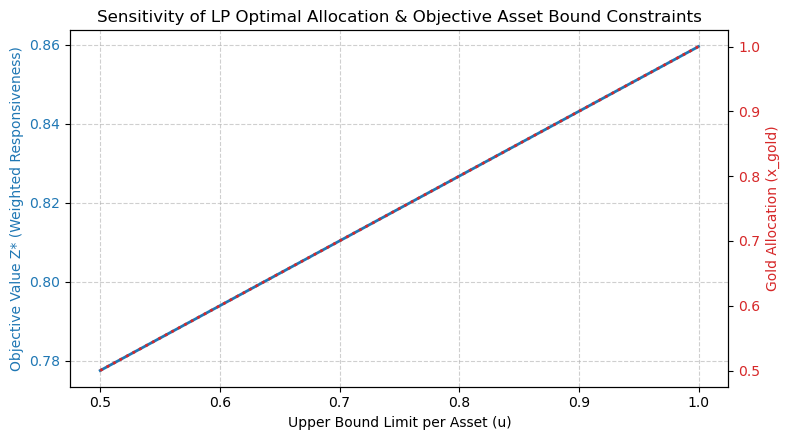

In [46]:
#Create bounds 
bounds_range = np.linspace(0.5, 1.0, 51)

#Compile constraints by starting with an empty list
obj_values = []
gold_allocs = []

for u in bounds_range: #max allocation per asset = u
    c = [-r_gold, -r_iron]
    A_eq = [[1,1]]
    b_eq = [1]
    bounds = [(0, u), (0,u)]
    
    #Call LP solver
    res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds)
    
    if res.success:
        obj_values.append(-res.fun) #Negate value Z* and append to obj_values
        gold_allocs.append(res.x[0]) #1st element in the sol'n array is x_gold
                                    #so add to gold_allocs list
        
#Plot sensitivity curve
fig, ax1 = plt.subplots(figsize=(8, 4.5))

color = 'tab:blue'
ax1.set_xlabel('Upper Bound Limit per Asset (u)')
ax1.set_ylabel('Objective Value Z* (Weighted Responsiveness)', color=color)
ax1.plot(bounds_range, obj_values, color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2=ax1.twinx()
color='tab:red'
ax2.set_ylabel('Gold Allocation (x_gold)', color=color)
ax2.plot(bounds_range, gold_allocs, color=color, linewidth=2, linestyle=':')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Sensitivity of LP Optimal Allocation & Objective Asset Bound Constraints')
fig.tight_layout()
plt.show()

In conclusion, LP model's strong allocation preference for Gold reflects its higher historical price responsiveness relative to Iron Ore. This aligns with the aforementioned forecast on projected Gold earnings to grow by $73 million, supporting the strong performance outlook for the asset.

Furthermore, by sweeping the single-asset upper bound constraint (u) from 0.5 to 1.0, it shows that the LP model consistently maximizes the overall portfolio score Z* by allocating as much budget to Gold under a limit. This shows that budget allocation within this specific framework depends entirely on artificial cap constraint rather than internal risks-balancing mechanisms within the system.